# **MÓDULO 39 - Exercicio - Aplicando XGboost**

Nessa atividade vocês usarão uma base já connhecida, a base de propensão a compra de carros.
Já utilizamos essa base antes, nessa atividade, você deve carregar a base, realizar os tratamentos necessários, rodar o XGBoost, encontrar as principais variaveis.
Vamos lá!

In [5]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 660.6 kB/s eta 0:02:34
   ---------------------------------------- 0.8/101.7 MB 10.1 MB/s eta 0:00:10
   - -------------------------------------- 3.2/101.7 MB 25.5 MB/s eta 0:00:04
   --- ------------------------------------ 8.3/101.7 MB 48.2 MB/s eta 0:00:02
   ---- ----------------------------------- 11.1/101.7 MB 81.8 MB/s eta 0:00:02
   ------ --------------------------------- 16.5/101.7 MB 81.8 MB/s eta 0:00:02
   ------- ------------------------------- 20.8/101.7 MB 110.0 MB/s eta 0:00:01
   ---------- ---------------------------- 26.3/101.7 MB 108.8 MB/s eta 0:00:01
   ------------ -------------------------- 31.7/101.7 MB 108.8 MB/s eta 0:00:01
   -------------- ------------------------ 37.2/101.7 MB 108.8 MB/s eta 0:00:01
   ---------------- ---------------------- 42.8/101.7 MB 108.8 MB/s eta 0:00:01
   ------------------ -------------------- 48.2/101.

In [9]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.


In [11]:
df = pd.read_csv("CARRO_CLIENTES.csv")

print(df.shape)
print(df.head())
print(df.info())
print("\nNulos:")
print(df.isnull().sum())

(1000, 5)
   User ID Gender  Age  AnnualSalary  Purchased
0      385   Male   35         20000          0
1      681   Male   40         43500          0
2      353   Male   49         74000          0
3      895   Male   40        107500          1
4      661   Male   25         79000          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User ID       1000 non-null   int64 
 1   Gender        1000 non-null   object
 2   Age           1000 non-null   int64 
 3   AnnualSalary  1000 non-null   int64 
 4   Purchased     1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB
None

Nulos:
User ID         0
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64


In [13]:
# Drop da coluna ID
df = df.drop(columns=['User ID'])

print(df.shape)
print(df.head())

(1000, 4)
  Gender  Age  AnnualSalary  Purchased
0   Male   35         20000          0
1   Male   40         43500          0
2   Male   49         74000          0
3   Male   40        107500          1
4   Male   25         79000          0


# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

In [15]:
le = LabelEncoder()
df['Gender_encoded'] = le.fit_transform(df['Gender'])

# Excluir coluna categorica original
df = df.drop(columns=['Gender'])

print(df.head())
print("\nGender encoded: 0 =", le.inverse_transform([0])[0], "| 1 =", le.inverse_transform([1])[0])

   Age  AnnualSalary  Purchased  Gender_encoded
0   35         20000          0               1
1   40         43500          0               1
2   49         74000          0               1
3   40        107500          1               1
4   25         79000          0               1

Gender encoded: 0 = Female | 1 = Male


# 3. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

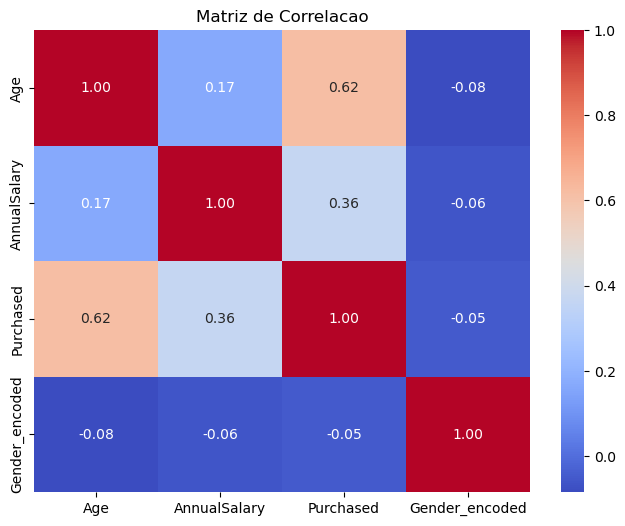


Correlacao com Purchased:
Purchased         1.000000
Age               0.616036
AnnualSalary      0.364974
Gender_encoded   -0.047211
Name: Purchased, dtype: float64


In [17]:
correlacao = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlacao')
plt.show()

print("\nCorrelacao com Purchased:")
print(correlacao['Purchased'].sort_values(ascending=False))

### Etapa 3 - Matriz de Correlacao

A variavel com maior correlacao com Purchased e Age (0.62),
indicando uma relacao moderada a forte: clientes mais velhos
tendem a comprar mais carros.

AnnualSalary tem correlacao moderada (0.36), tambem
contribuindo positivamente para a decisao de compra.

Gender_encoded tem correlacao praticamente nula (-0.05),
sugerindo que o genero nao influencia significativamente
a decisao de compra nessa base.

# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

In [20]:
X = df.drop(columns=['Purchased'])
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("\nBalanceamento y_train:")
print(y_train.value_counts(normalize=True).mul(100).round(1))

X_train: (800, 3)
X_test: (200, 3)

Balanceamento y_train:
Purchased
0    60.8
1    39.2
Name: proportion, dtype: float64


# 5. Treino o modelo Xgboost com sua base de treino.
Pesquise alguns hyperparametros na bibllioteca para utilizar, utilize ao menos 2.

In [22]:
modelo_xgb = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

modelo_xgb.fit(X_train, y_train)

print("Modelo treinado com sucesso!")
print("\nHiperparametros utilizados:")
print("n_estimators: 100 (numero de arvores)")
print("max_depth: 4 (profundidade maxima de cada arvore)")
print("learning_rate: 0.1 (taxa de aprendizado)")

Modelo treinado com sucesso!

Hiperparametros utilizados:
n_estimators: 100 (numero de arvores)
max_depth: 4 (profundidade maxima de cada arvore)
learning_rate: 0.1 (taxa de aprendizado)


# 6. Realize as previsões para a base de teste e traga as probabilidades das previsões.

In [24]:
# Probabilidades
y_prob = modelo_xgb.predict_proba(X_test)

print("Primeiras 10 probabilidades:")
print(y_prob[:10])
print("\nFormato: [P(classe 0), P(classe 1)]")

Primeiras 10 probabilidades:
[[7.9455054e-01 2.0544949e-01]
 [3.9580762e-02 9.6041924e-01]
 [9.9917769e-01 8.2227745e-04]
 [8.5210264e-01 1.4789733e-01]
 [2.9719585e-01 7.0280415e-01]
 [4.5103431e-02 9.5489657e-01]
 [5.5320263e-03 9.9446797e-01]
 [9.9858832e-01 1.4116646e-03]
 [9.8977500e-01 1.0225001e-02]
 [9.9049234e-01 9.5076421e-03]]

Formato: [P(classe 0), P(classe 1)]


# 7. Faça a transformação das probabilidades nas previsões binárias e avalie o desempenho do modelo.

Acuracia: 0.915

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       112
           1       0.94      0.86      0.90        88

    accuracy                           0.92       200
   macro avg       0.92      0.91      0.91       200
weighted avg       0.92      0.92      0.91       200



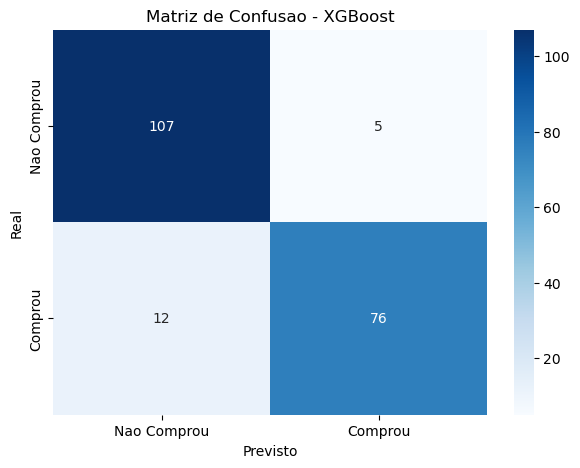

In [26]:
# Previsoes binarias
y_pred = modelo_xgb.predict(X_test)

# Metricas
print("Acuracia:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Matriz de confusao
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Nao Comprou', 'Comprou'],
            yticklabels=['Nao Comprou', 'Comprou'])
plt.title('Matriz de Confusao - XGBoost')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

### Etapa 7 - Avaliacao do Modelo

Acuracia: 91.5%

O modelo apresentou desempenho muito bom:
- Classe 0 (Nao Comprou): precision 0.90, recall 0.96
- Classe 1 (Comprou): precision 0.94, recall 0.86

Pela matriz de confusao:
- 107 acertos para "Nao Comprou" e apenas 5 erros
- 76 acertos para "Comprou" e 12 erros

O modelo erra mais ao classificar quem realmente comprou
como "nao comprou" (12 casos), mas o desempenho geral e
excelente para esse tipo de problema de negocio.

# 8. Traga a lista com a feature importance.
As features mais importantes são as mesmas que indicaram maior correlação na matriz de correlação?

Importancia das variaveis:
Age               0.592273
AnnualSalary      0.320791
Gender_encoded    0.086936
dtype: float32


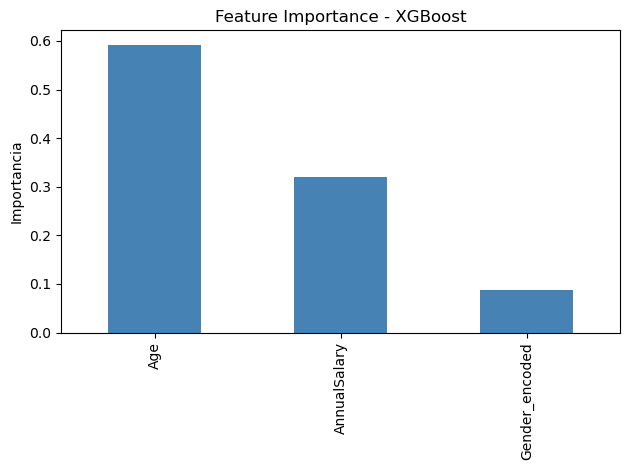

In [29]:
importancias = pd.Series(
    modelo_xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Importancia das variaveis:")
print(importancias)

importancias.plot(kind='bar', color='steelblue')
plt.title('Feature Importance - XGBoost')
plt.ylabel('Importancia')
plt.tight_layout()
plt.show()